<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [8]:
import pandas as pd

pd.Series(dataset['train']['text'])

0        I rented I AM CURIOUS-YELLOW from my video sto...
1        "I Am Curious: Yellow" is a risible and preten...
2        If only to avoid making this type of film in t...
3        This film was probably inspired by Godard's Ma...
4        Oh, brother...after hearing about this ridicul...
                               ...                        
24995    A hit at the time but now better categorised a...
24996    I love this movie like no other. Another time ...
24997    This film and it's sequel Barry Mckenzie holds...
24998    'The Adventures Of Barry McKenzie' started lif...
24999    The story centers around Barry McKenzie who mu...
Length: 25000, dtype: object

In [9]:
sent_tokenize(dataset['train']['text'][5], language='english')
word_tokenize(sent_tokenize(dataset['train']['text'][5], language='english')[0])

['I',
 'would',
 'put',
 'this',
 'at',
 'the',
 'top',
 'of',
 'my',
 'list',
 'of',
 'films',
 'in',
 'the',
 'category',
 'of',
 'unwatchable',
 'trash',
 '!']

In [6]:
sentences = []
word_threshold = 32

for sentence in tqdm(dataset['train']['text']):
    # print([[w for w in word_tokenize(x)] for x in sent_tokenize(sentence, language='english')])
    # break
    sentences.extend(
        [[word for word in word_tokenize(x)] for x in sent_tokenize(sentence, language='english') if len(word_tokenize(x)) < word_threshold]
        )

# Получить отдельные предложения и поместить их в sentences

  0%|          | 0/25000 [00:00<?, ?it/s]

In [11]:
print("Всего предложений:", len(sentences))

Всего предложений: 198801


Посчитаем для каждого слова его встречаемость.

In [7]:
words = Counter()

for sentence in tqdm(sentences):
    for word in sentence:
        words[word] += 1

  0%|          | 0/198801 [00:00<?, ?it/s]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [8]:
# vocab = set()
vocab_size = 40000

special_tokens = ['<unk>', '<bos>', '<eos>', '<pad>']
counter_threshold = 500

vocab = set(special_tokens + [word for word, cnt in words.most_common(vocab_size)][: vocab_size])

In [9]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [16]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [12]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [17]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = []
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in self.data[idx]]
        tokenized_sentence += [self.eos_id]
        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [18]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [15]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [16]:
for batch in train_dataloader:
    print([ind2word[token.item()] for token in batch["input_ids"][0]])
    break
# Простая проверка на самые глупые ошибки при токенизации

['<bos>', 'I', 'want', 'to', 'go', 'back', 'in', 'time', 'and', 'cut', 'my', 'wrist', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [19]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            # logits = # Посчитайте логиты предсказаний следующих слов
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [23]:
def fit_and_result(model, criterion, optimizer, train_dataloader, eval_dataloader, num_epoch, n_eval_steps_for_epoch=2):
    eval_steps = len(train_dataloader) // n_eval_steps_for_epoch
    losses = []
    perplexities = []

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits.flatten(start_dim=0, end_dim=1), batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                val_perplexity = evaluate(model, criterion, eval_dataloader)
                perplexities.append(val_perplexity)
                model.train()
        losses.append(sum(epoch_losses) / len(epoch_losses))
    return {
        "losses": losses,
        "perplexities": perplexities
    }

In [24]:
def plot_results(results: dict):
    colors = ['red', 'blue', 'green', 'black', 'pink', 'grey', 'orange', 'purple', 'magenta', 'gold'][::-1]
    colors_ = colors[::]
    for name in results:
        plt.plot(np.arange(len(results[name]["losses"])), results[name]["losses"], color=colors_.pop(), label=name)
    plt.title('Losses')
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

    for name in results:
        plt.plot(np.arange(len(results[name]["perplexities"][1:])), results[name]["perplexities"][1:], color=colors.pop(), label=name)
        print(f"Лучший perplexity для подхода {name}: {(min(results[name]["perplexities"]))}")
    plt.title('Perplexity')
    plt.xlabel("epoch")
    plt.legend()
    plt.show()
    for name in results:
        print(name, results[name]["perplexities"])

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [21]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]

        return projection

In [24]:
model = LanguageModel(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())
                        #model, criterion, optimizer, train_dataloader, eval_dataloader, num_epoch, n_eval_steps_for_epoch=2
results = fit_and_result(model, criterion, optimizer, train_dataloader, eval_dataloader, num_epoch=10)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

In [26]:
results = {"model1": results}

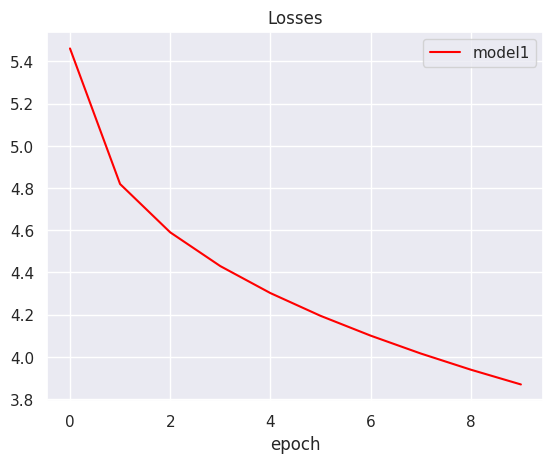

Лучший perplexity для подхода model1: 56.628342460327936


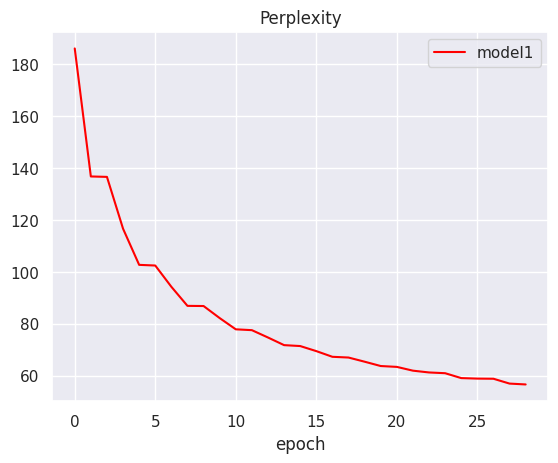

model1 [38426.0999135296, 186.1410250080752, 136.8015501594298, 136.63331465555433, 116.659322927664, 102.72625765806613, 102.46952861064189, 94.27073222667248, 86.9189427497304, 86.85760909464675, 82.20949031579448, 77.87912666291344, 77.5519670120691, 74.72242231626768, 71.78253902400937, 71.42868288941058, 69.47694752912878, 67.28617257470484, 67.00172224498931, 65.3981594345898, 63.72953707524402, 63.39695742691806, 61.94204838088734, 61.25126172216702, 60.96225714468741, 59.07753493948486, 58.88345252470314, 58.82794158523147, 56.961020245054975, 56.628342460327936]


In [29]:
plot_results(results)

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [45]:
class LanguageModel_Experiment2(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_layers: int = 2, dropout_prob: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]
        return projection


In [27]:
model2 = LanguageModel_Experiment2(hidden_dim=512, vocab_size=len(vocab), num_layers=2, dropout_prob=0.3).to(device)
criterion2 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)

In [36]:
results_exp2 = fit_and_result(model2, criterion2, optimizer2, train_dataloader, eval_dataloader, num_epoch=10)


Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

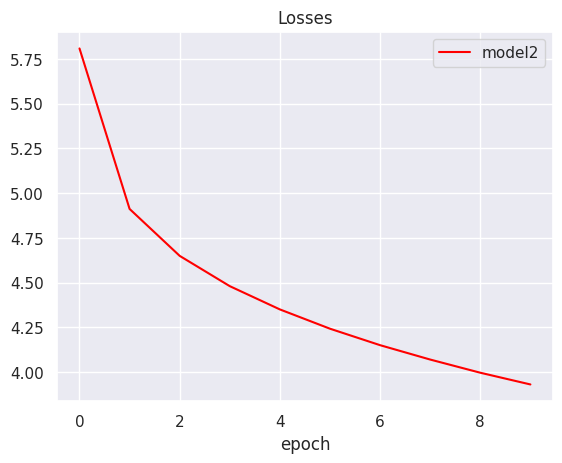

Лучший perplexity для подхода model2: 53.794008856421115


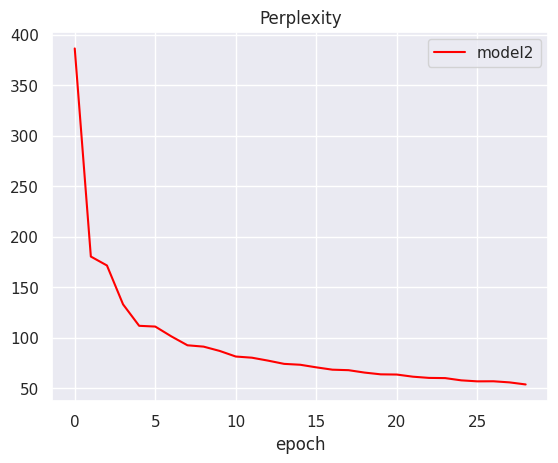

model2 [36127.48947273166, 386.3823336057528, 180.4026707436894, 171.55831691196985, 133.0873884792647, 111.833646835661, 111.09088120037065, 101.36794470513343, 92.55902046586556, 91.23224120465332, 86.97315835645914, 81.42579318995335, 80.27993170543067, 77.38934362011373, 74.16871912108118, 73.29272355873766, 70.72147887339156, 68.41434459121685, 67.92096617415145, 65.53682971890522, 63.802194160844365, 63.59576242218607, 61.46884992837599, 60.273648471905915, 60.08009972197976, 57.85264547144278, 56.86069893560815, 56.936608612767515, 55.836241738062874, 53.794008856421115]


In [38]:
results = {}
results["model2"] = results_exp2
plot_results(results)

In [21]:
class LanguageModel_Experiment3(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_layers: int = 1, dropout_prob: float = 0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.linear = nn.Linear(hidden_dim, hidden_dim // 2)
        self.projection = nn.Linear(hidden_dim // 2, vocab_size)

        self.non_lin = nn.ReLU() 
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.norm(output) # Apply Layer Normalization
        output = self.dropout(self.non_lin(self.linear(output))) # [batch_size, seq_len, hidden_dim // 2]
        projection = self.projection(output)  # [batch_size, seq_len, vocab_size]

        return projection


In [25]:
model3 = LanguageModel_Experiment3(hidden_dim=256, vocab_size=len(vocab), num_layers=1, dropout_prob=0.2).to(device)
criterion3 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.001)

results_exp3 = fit_and_result(model3, criterion3, optimizer3, train_dataloader, eval_dataloader, num_epoch=10)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

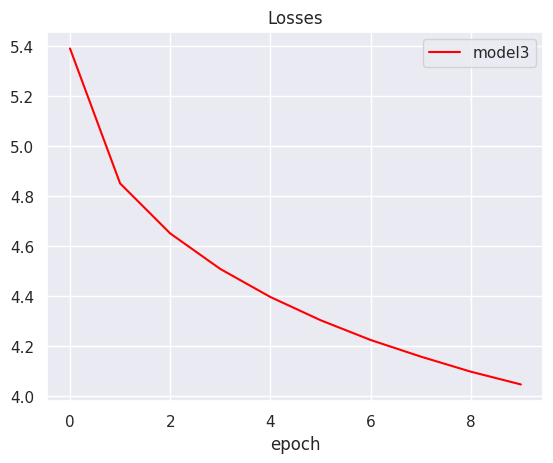

Лучший perplexity для подхода model3: 60.81454273847386


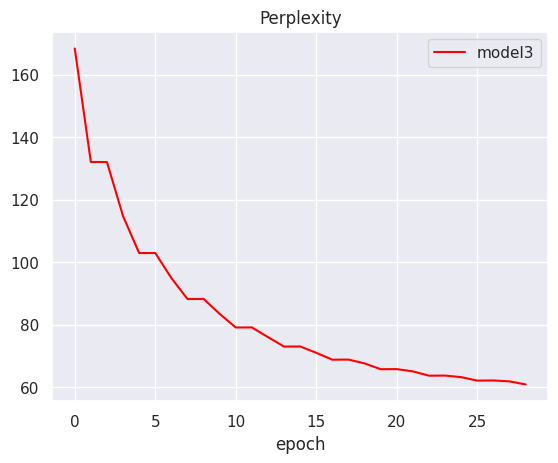

model3 [36068.78854971042, 168.36316766333857, 132.0272551626159, 131.99657928191863, 114.67160067564426, 102.86813837588984, 102.88424945767476, 94.8748810717805, 88.15795439888305, 88.19207502485395, 83.39971591453602, 79.04143606649863, 79.06631262544806, 75.96478424661409, 72.92923767502243, 72.97389818680026, 70.92704984058591, 68.73672294862175, 68.77284521056265, 67.55133891750026, 65.6911224257225, 65.72101702008929, 64.9966871637175, 63.61522800244266, 63.655010724159744, 63.141790490659815, 62.03899707573261, 62.08893191952503, 61.79580882402614, 60.81454273847386]


In [27]:
results = {}
results["model3"] = results_exp3

plot_results(results)

In [32]:
def generate_sequence(model, starting_seq: str, max_seq_len: int = 128):
    model.eval()
    model = model.to(device)
    tokenized_starting_seq = word_tokenize(starting_seq, language='english')
    input_ids = [word2ind['<bos>']] + [
        word2ind.get(word, word2ind['<unk>']) for word in tokenized_starting_seq
    ]
    input_tensor = torch.LongTensor(input_ids).unsqueeze(0).to(device)

    generated_word_indices = []

    with torch.no_grad():
        for _ in range(max_seq_len):
            output_logits = model(input_tensor)[:, -1, :]
            next_word_idx = torch.argmax(output_logits, dim=-1).item()
            if next_word_idx == word2ind['<eos>']:
                break
            generated_word_indices.append(next_word_idx)
            input_tensor = torch.cat([input_tensor, torch.LongTensor([next_word_idx]).unsqueeze(0).to(device)], dim=1)

    final_word_indices = [word2ind.get(word, word2ind['<unk>']) for word in tokenized_starting_seq] + generated_word_indices
    final_words = [ind2word[idx] for idx in final_word_indices]
    return ' '.join(final_words)

In [44]:
generate_sequence(model2, starting_seq='man')

'man is a great actor , but he is not a good actor .'

In [46]:
torch.save(model2.state_dict(), 'model2.pt')

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

### Эксперемент 1
Первая модель основывалась на однослойном LSTM <br>
Она показала за 10 эпох обучения perplexity = 56.628342460327936
### Эксперемент 2
Вторая модель отличается от первой тем что она имеет два слоя LSTM с dropout = 0.2 <br>
Она показала за 10 эпох обучения perplexity = 53.794008856421115<br>
### Эксперемент 3
Третья модель основывается на однослойном GRU, dropout = 0.2, и функция активации была сменена с tanh на ReLU<br>
Она показала за 10 эпох обучения perplexity = 60.81454273847386<br>

### Общие выводы
В целом мы видим что чем сложнее модель тем лучше результаты<br>
Кроме того видим что нет намека на переобучения и графики лосса и перплексити хоть и деградируют со временем, но не останавливаются, что наводит на мысль что при усложнении модели и увеличении количества эпох результат будет сильно лучше.